# 02 — Baseline vs Sampling 

| # |          |        |
|---|----------|--------|
| 1 | Baseline (No Sampling) |train mô hình trên dữ liệu thô  |
| 2 | Random Under-sampling | Giảm majority class |
| 3 | SMOTE | Tạo synthetic minority samples |

In [5]:
%matplotlib inline
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from src.config import REPORTS_DIR
from src.preprocessing import load_data, scale_features, split_data
from src.preprocessing import get_sampled_data
from src.models import get_model, get_model_display_name
from src.evaluator import evaluate_model

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

Tách tập train và tập test

In [6]:
# Load & preprocess
df = load_data()
df = scale_features(df, fit=True)
X_train, X_test, y_train, y_test = split_data(df)

print(f'Training set: {len(X_train):,} samples')
print(f'Test set:     {len(X_test):,} samples')
print(f'Train fraud ratio: {y_train.mean()*100:.3f}%')

Training set: 227,845 samples
Test set:     56,962 samples
Train fraud ratio: 0.173%


## 1.  Baseline — Tất cả mô hình trên dữ liệu thô

In [7]:
from src.config import MODEL_NAMES
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd
import matplotlib.pyplot as plt

baseline_metrics = []
predictions_baseline = {}

### 1.1 Random Forest


  Training Random Forest on Baseline (No Sampling)...

──────────────────────────────────────────────────
  Random Forest (baseline)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



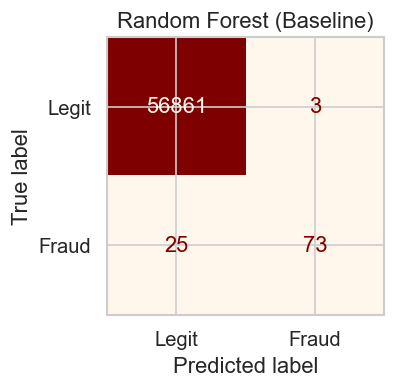

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Random Forest,0.9995,0.9605,0.7449,0.8391,0.9529,0.8556


In [8]:
model_name = 'random_forest'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} on Baseline (No Sampling)...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
predictions_baseline[model_name] = y_pred

# Evaluate and get metrics
metrics = evaluate_model(model, X_test, y_test, model_name, 'baseline')
baseline_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

# Display confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Baseline)')
plt.show()

# Display metrics DataFrame
pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình Random Forest (Baseline) thể hiện hiệu suất rất ấn tượng với độ chính xác (Precision) đạt 96.05%, cho thấy mô hình có độ tin cậy cao khi dự đoán gian lận, với số lượng cảnh báo sai tương đối thấp (chỉ có 3 trường hợp báo động nhầm trong tổng số 56,861 mẫu kiểm tra). Mô hình đạt được chỉ số bao phủ (Recall) khoảng 74.49%, cho thấy khả năng nhận diện hiệu quả một phần lớn các vụ gian lận thực tế, tuy nhiên vẫn còn bỏ sót khoảng 25.5% số vụ vi phạm. Chỉ số F1-score đạt mức 83.91%, phản ánh sự cân bằng khá tốt giữa khả năng bắt đúng gian lận và việc hạn chế tối đa các sai sót không đáng có.

### 1.2 Logistic Regression


  Training Logistic Regression on Baseline (No Sampling)...

──────────────────────────────────────────────────
  Logistic Regression (baseline)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



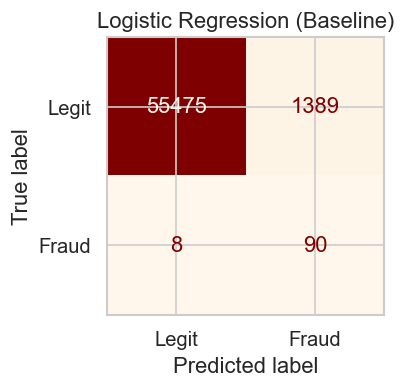

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Logistic Regression,0.9755,0.0609,0.9184,0.1141,0.972,0.7189


In [9]:
model_name = 'logistic_regression'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} on Baseline (No Sampling)...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
predictions_baseline[model_name] = y_pred

# Evaluate and get metrics
metrics = evaluate_model(model, X_test, y_test, model_name, 'baseline')
baseline_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

# Display confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Baseline)')
plt.show()

# Display metrics DataFrame
pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình Logistic Regression (Baseline) thể hiện một hiệu suất khá lệch: mặc dù có chỉ số bao phủ (Recall) rất cao, đạt khoảng 91.84%, cho thấy khả năng bắt được hầu hết các giao dịch gian lận thực tế. Tuy nhiên, độ chính xác (Precision) của mô hình lại cực kỳ thấp, chỉ dừng ở mức 6.09%, điều này có nghĩa là khi mô hình đưa ra cảnh báo gian lận thì khả năng đó là chính xác rất thấp, dẫn đến việc flag nhầm một lượng lớn khách hàng lương thiện (cụ thể có tới 1,389 trường hợp báo động nhầm trong ma trận nhầm lẫn). Chỉ số F1-score rất thấp, chỉ khoảng 11.41%, phản ánh sự mất cân bằng nghiêm trọng giữa Precision và Recall, cho thấy mô hình baseline này đang bị quá thiên kiến (bias) và chưa hiệu quả khi hoạt động trên dữ liệu thô chưa qua xử lý cân bằng.

### 1.3 K-Nearest Neighbors


  Training K-Nearest Neighbors on Baseline (No Sampling)...

──────────────────────────────────────────────────
  K-Nearest Neighbors (baseline)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.92      0.79      0.85        98

    accuracy                           1.00     56962
   macro avg       0.96      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962



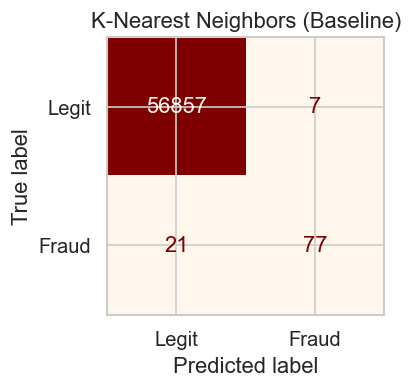

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
K-Nearest Neighbors,0.9995,0.9167,0.7857,0.8462,0.9438,0.8449


In [10]:
model_name = 'knn'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} on Baseline (No Sampling)...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
predictions_baseline[model_name] = y_pred

# Evaluate and get metrics
metrics = evaluate_model(model, X_test, y_test, model_name, 'baseline')
baseline_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

# Display confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Baseline)')
plt.show()

# Display metrics DataFrame
pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình K-Nearest Neighbors (Baseline) đạt được hiệu suất khá cân bằng với độ chính xác (Precision) là 91.67%, cho thấy độ tin cậy cao khi mô hình xác định một giao dịch là gian lận. Chỉ số bao phủ (Recall) đạt mức 78.57%, phản ánh khả năng nhận diện tốt các vụ gian lận thực tế, dù vẫn để sót một lượng nhỏ các trường hợp vi phạm (21 vụ). Với chỉ số F1-score khoảng 84.62%, KNN cho thấy sự kết hợp hiệu quả giữa khả năng dự đoán chính xác và khả năng bao quát dữ liệu .

### 1.4 Support Vector Machine


  Training Support Vector Machine on Baseline (No Sampling)...

──────────────────────────────────────────────────
  Support Vector Machine (baseline)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.25      0.80      0.38        98

    accuracy                           1.00     56962
   macro avg       0.62      0.90      0.69     56962
weighted avg       1.00      1.00      1.00     56962



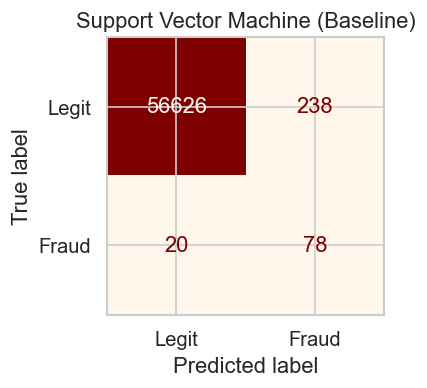

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Support Vector Machine,0.9955,0.2468,0.7959,0.3768,0.9755,0.4363


In [11]:
model_name = 'svm'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} on Baseline (No Sampling)...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
predictions_baseline[model_name] = y_pred

# Evaluate and get metrics
metrics = evaluate_model(model, X_test, y_test, model_name, 'baseline')
baseline_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

# Display confusion matrix
fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
display = ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Baseline)')
plt.show()

# Display metrics DataFrame
pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình Support Vector Machine (Baseline) cho thấy hiệu suất ở mức trung bình: chỉ số bao phủ (Recall) đạt 79.59%, giúp bắt được phần lớn các giao dịch gian lận thực tế. Tuy nhiên, độ chính xác (Precision) chỉ đạt 24.68%, cho thấy mô hình vẫn đưa ra khá nhiều cảnh báo sai (234 trường hợp báo động nhầm trong ma trận nhầm lẫn). Với chỉ số F1-score khoảng 37.68%, SVM hoạt động tốt hơn Logistic Regression nhưng vẫn kém hiệu quả rõ rệt so với Random Forest hay KNN trong việc cân bằng giữa khả năng nhận diện gian lận và hạn chế sai sót trên dữ liệu thô.

### 1.5 Performance comparison

In [12]:
baseline_df = pd.DataFrame(baseline_metrics)
print('\n📊 All Models — Baseline (No Sampling):')
print(baseline_df.to_string(index=False))
baseline_df.to_csv(REPORTS_DIR / 'all_models_baseline.csv', index=False)



📊 All Models — Baseline (No Sampling):
                 Model  accuracy  precision  recall  f1_score  auc_roc  auc_pr
         Random Forest    0.9995     0.9605  0.7449    0.8391   0.9529  0.8556
   Logistic Regression    0.9755     0.0609  0.9184    0.1141   0.9720  0.7189
   K-Nearest Neighbors    0.9995     0.9167  0.7857    0.8462   0.9438  0.8449
Support Vector Machine    0.9955     0.2468  0.7959    0.3768   0.9755  0.4363


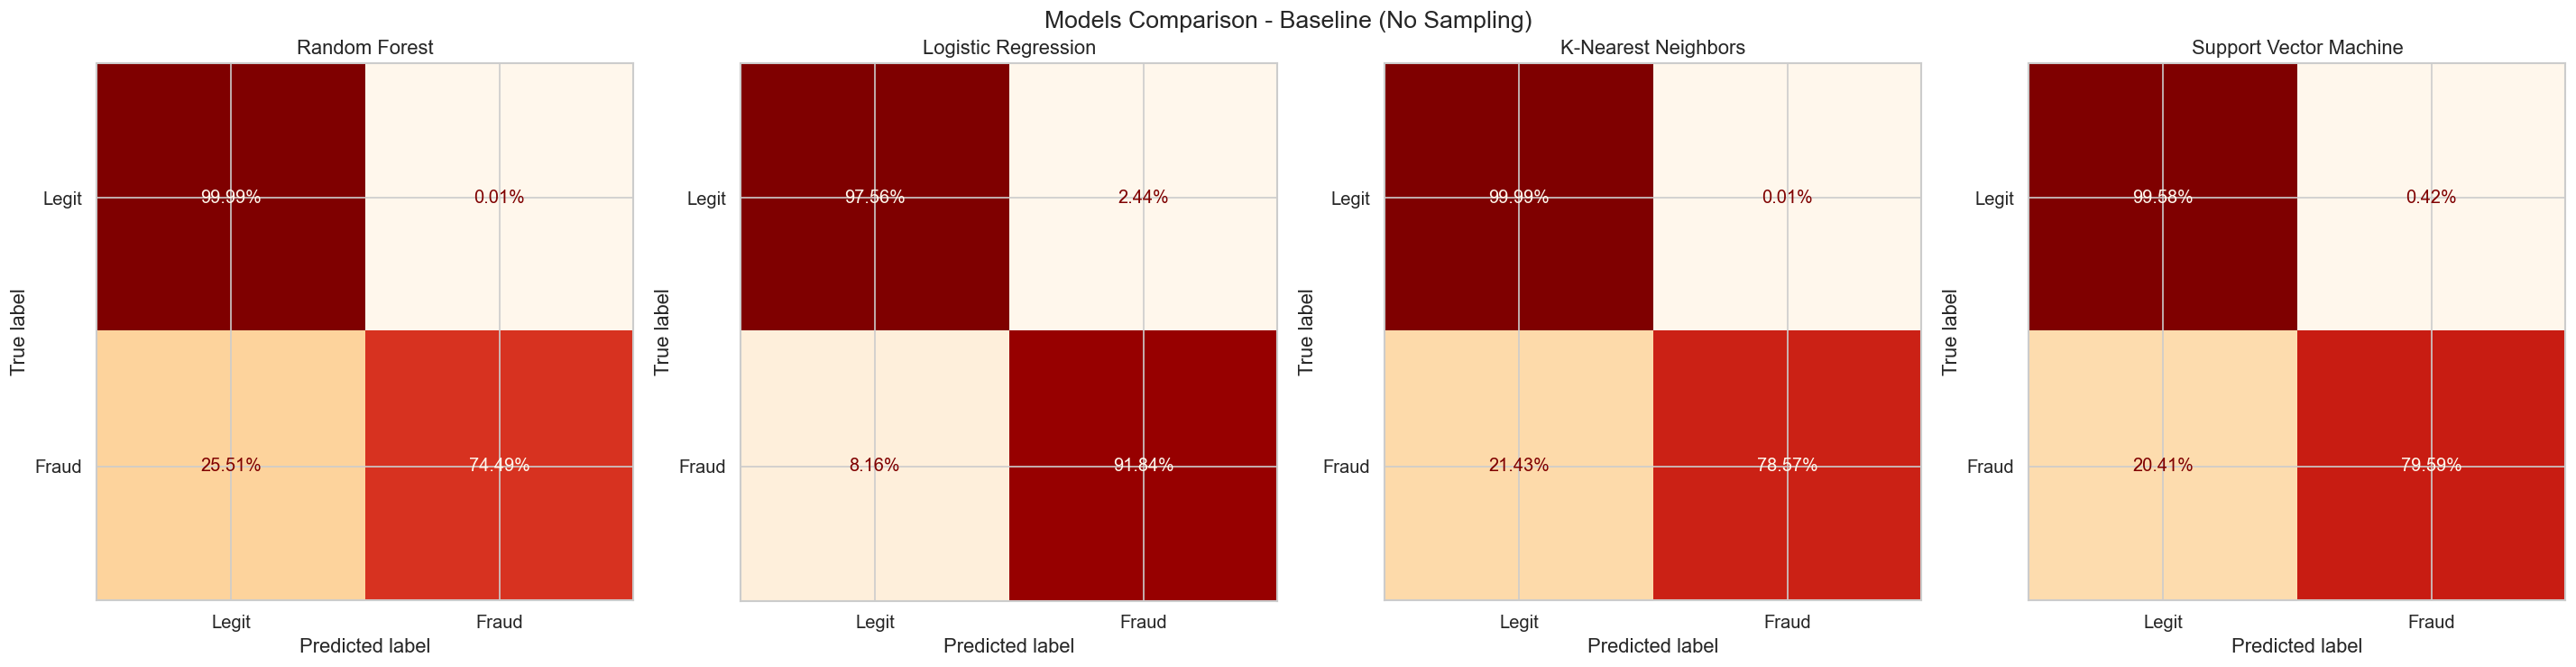

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Models Comparison - Baseline (No Sampling)', fontsize=16)

for j, model_name in enumerate(MODEL_NAMES):
    ax = axes[j]
    ax.set_title(f'{get_model_display_name(model_name)}')
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        predictions_baseline[model_name], 
        display_labels=display_labels, 
        ax=ax, 
        cmap='OrRd', 
        colorbar=False, normalize='true', values_format='.2%', text_kw={'fontsize':12})
    
    
plt.tight_layout()
plt.show()

## 2. Các mô hình dự đoán (Sử dụng Random Under-sampling)

Trong phần này, chúng ta áp dụng kỹ thuật Random Under-sampling (Lấy mẫu dưới ngẫu nhiên) vào tập huấn luyện để xử lý tình trạng mất cân bằng lớp nghiêm trọng, sau đó đánh giá các mô hình trên tập kiểm tra "chưa từng thấy" (tập dữ liệu nguyên bản, không qua lấy mẫu).Cân bằng tỷ lệ giữa hai lớp bằng cách giảm số lượng mẫu của lớp đa số (giao dịch hợp lệ) sao cho bằng với lớp thiểu số (gian lận), giúp mô hình không bị "học lệch".

In [14]:
X_under, y_under = get_sampled_data(X_train, y_train, strategy='undersample')
print(f'Under-sampled training set: {len(X_under):,} samples')
print(f'Class distribution: {pd.Series(y_under).value_counts().to_dict()}')

under_metrics = []
predictions_under = {}

Under-sampled training set: 788 samples
Class distribution: {0: 394, 1: 394}


### 2.1 Random Forest


  Training Random Forest with Under-sampling...

──────────────────────────────────────────────────
  Random Forest (undersample)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     56864
       Fraud       0.04      0.91      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



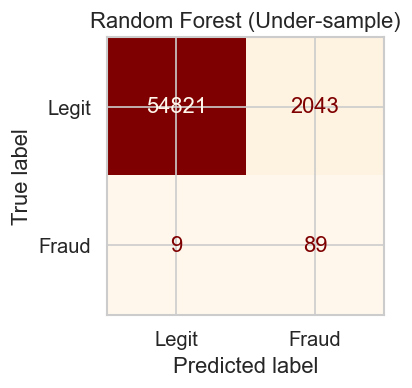

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Random Forest,0.964,0.0417,0.9082,0.0798,0.9778,0.6956


In [15]:
model_name = 'random_forest'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with Under-sampling...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_under, y_under)
y_pred = model.predict(X_test)
predictions_under[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'undersample')
under_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Under-sample)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình Random Forest (với Random Under-sampling) cho thấy một sự thay đổi rõ rệt trong chiến lược dự đoán: chỉ số bao phủ (Recall) tăng mạnh lên 90.82%, cho thấy mô hình rất nhạy trong việc phát hiện gian lận. Tuy nhiên, precision giảm xuống mức rất thấp (4.17%), dẫn đến số lượng cảnh báo sai tăng mạnh, làm giảm tính thực tế của mô hình. Điều này phản ánh sự đánh đổi lớn khi áp dụng kỹ thuật lấy mẫu dưới: mô hình bắt được nhiều gian lận hơn nhưng lại tạo ra một lượng khổng lồ các cảnh báo sai (2043 trường hợp báo động nhầm). Chỉ số F1-score chỉ đạt 7.98%, cho thấy sự mất cân bằng này làm giảm hiệu suất tổng thể của mô hình so với kịch bản baseline ban đầu.

### 2.2 Logistic Regression


  Training Logistic Regression with Under-sampling...

──────────────────────────────────────────────────
  Logistic Regression (undersample)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98     56864
       Fraud       0.04      0.92      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



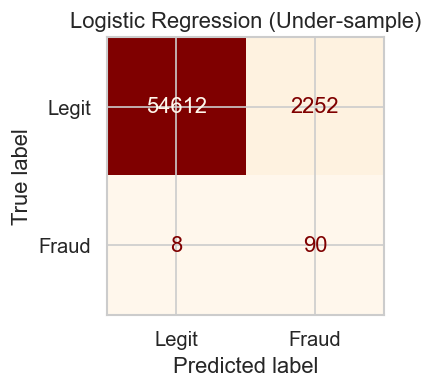

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Logistic Regression,0.9603,0.0384,0.9184,0.0738,0.9761,0.6933


In [16]:
model_name = 'logistic_regression'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with Under-sampling...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_under, y_under)
y_pred = model.predict(X_test)
predictions_under[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'undersample')
under_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Under-sample)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Tương tự như mô hình Random Forest, mô hình Logistic Regression (với Random Under-sampling) cũng cho thấy sự không cải thiện đáng kể so với baseline về recall (vẫn ~91.84%), nhưng precision tiếp tục giảm, với mức precision tương đối thấp chỉ khoảng 3.84%. Sự sụt giảm precision này là một sự đánh đổi thường gặp quan sát được trong các tập dữ liệu mất cân bằng sau khi áp dụng kỹ thuật lấy mẫu dưới (under-sampling), do việc cắt giảm số lượng lớp đa số khiến hệ thống nhầm lẫn và tạo ra các trường hợp báo động nhầm. Chỉ số F1 đứng ở mức 7.38%, phản ánh sự đánh đổi giữa precision và recall. Việc sụt giảm chỉ số F1 này là điều đã được dự báo trước do sự thỏa hiệp giữa hai chỉ số nhằm tối ưu hóa tối đa khả năng nhận diện các trường hợp gian lận thực tế.

### 2.3 K-Nearest Neighbors


  Training K-Nearest Neighbors with Under-sampling...

──────────────────────────────────────────────────
  K-Nearest Neighbors (undersample)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



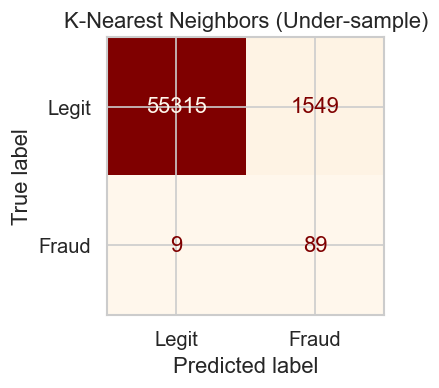

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
K-Nearest Neighbors,0.9726,0.0543,0.9082,0.1025,0.9646,0.2139


In [17]:
model_name = 'knn'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with Under-sampling...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_under, y_under)
y_pred = model.predict(X_test)
predictions_under[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'undersample')
under_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Under-sample)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Có một sự cải thiện đáng kể về chỉ số recall (đạt 90.82%) so với kết quả ban đầu của mô hình khi chưa áp dụng under-sampling, cho thấy mô hình đã tăng cường độ nhạy bén với các ca gian lận. Tuy nhiên, như đã quan sát thấy ở các mô hình khác, kỹ thuật under-sampling đã dẫn đến sự sụt giảm về độ chính xác (precision), dừng ở mức khoảng 5.43% (do có tới 1.549 trường hợp cảnh báo nhầm). Hệ quả là chỉ số F1-score chỉ đạt 10.25%, phản ánh rõ ràng sự đánh đổi giữa precision và recall khi xử lý tập dữ liệu mất cân bằng.

### 2.4 Support Vector Machine


  Training Support Vector Machine with Under-sampling...

──────────────────────────────────────────────────
  Support Vector Machine (undersample)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.98      0.99     56864
       Fraud       0.07      0.89      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.93      0.56     56962
weighted avg       1.00      0.98      0.99     56962



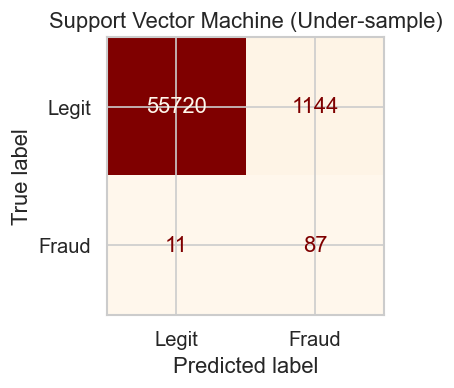

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Support Vector Machine,0.9797,0.0707,0.8878,0.1309,0.9786,0.6174


In [18]:
model_name = 'svm'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with Under-sampling...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_under, y_under)
y_pred = model.predict(X_test)
predictions_under[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'undersample')
under_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (Under-sample)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Chỉ số recall đạt 88.78% là tương đối cao, cho thấy mô hình SVM hoạt động hiệu quả khi nhận diện chính xác được khoảng 88.8% các giao dịch gian lận thực tế sau khi áp dụng under-sampling (bắt được 87/98 vụ). Đây là một sự cải thiện đáng chú ý so với các kết quả ban đầu khi chưa lấy mẫu. Mặt khác, độ chính xác (precision) ở mức khoảng 7.07% là khá thấp, ngụ ý rằng khi mô hình SVM dự đoán một giao dịch là gian lận, nó chỉ đúng trong khoảng 7.1% số lần cảnh báo (do có tới 1.144 ca báo nhầm). Chỉ số F1-score đạt 13.09% phản ánh sự đánh đổi đáng kể giữa precision và recall, làm nổi bật những thách thức trong việc đạt được sự cân bằng khi đối mặt với dữ liệu mất cân bằng

### 2.5 Performance comparison

In [19]:
under_df = pd.DataFrame(under_metrics)

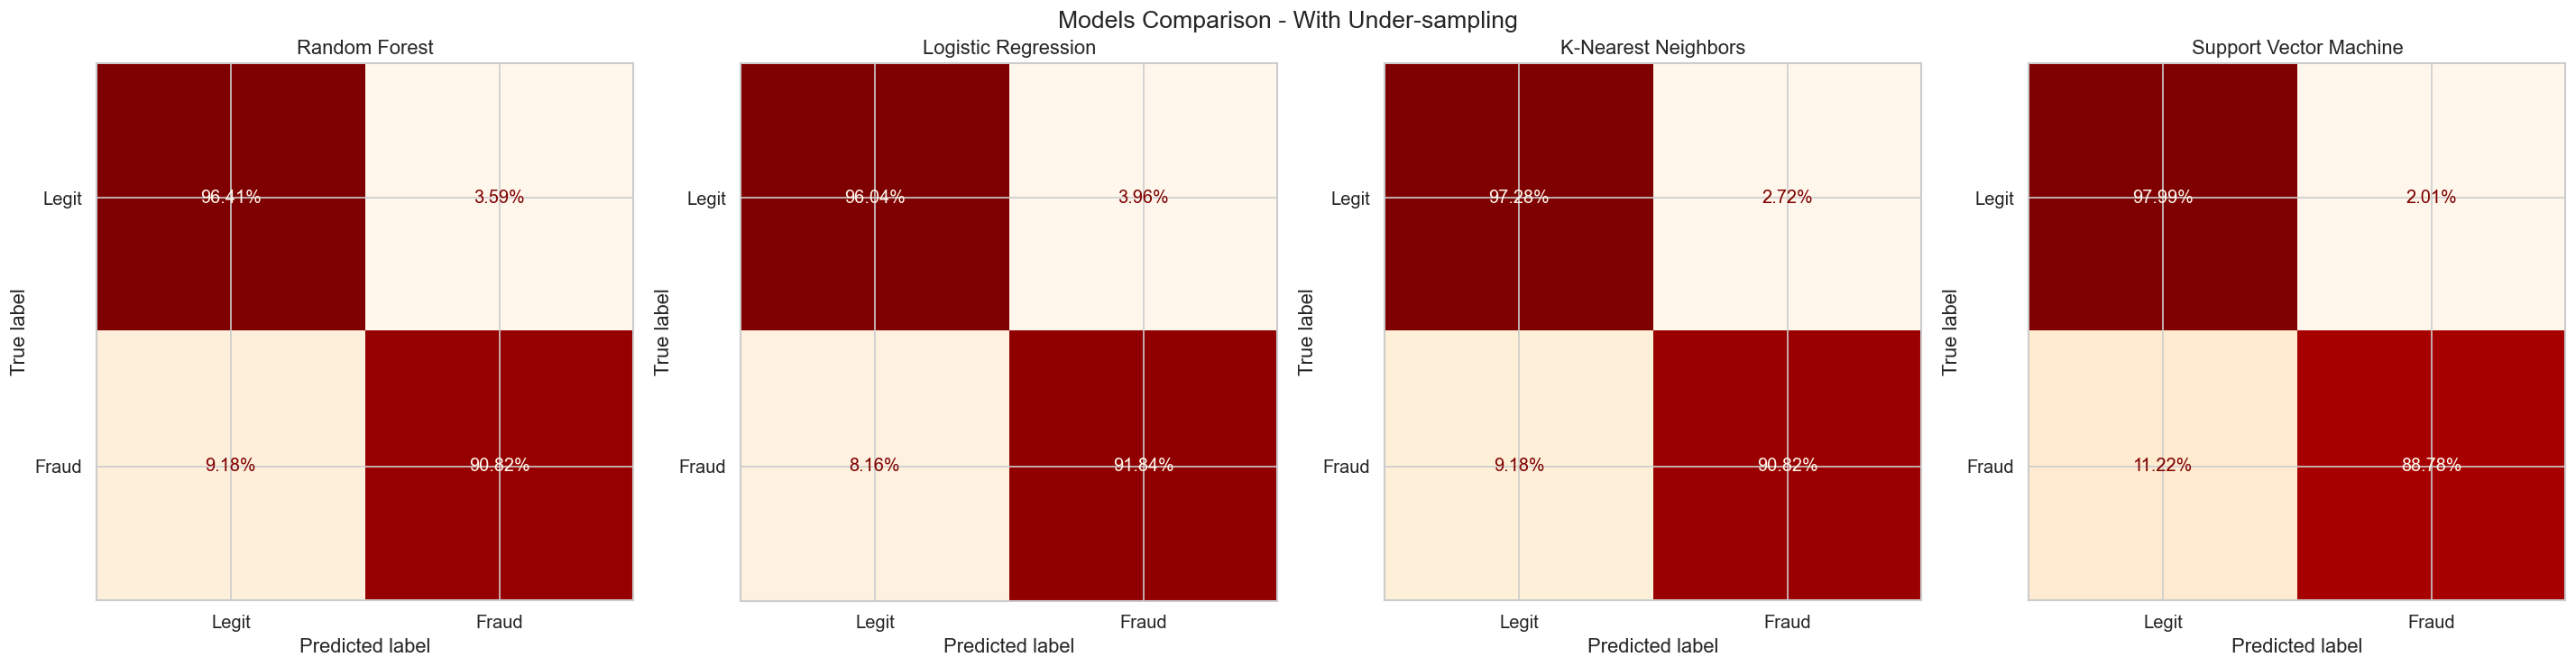

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Models Comparison - With Under-sampling', fontsize=16)

for j, model_name in enumerate(MODEL_NAMES):
    ax = axes[j]
    ax.set_title(f'{get_model_display_name(model_name)}')
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        predictions_under[model_name], 
        display_labels=display_labels, 
        ax=ax, 
        cmap='OrRd', 
        colorbar=False, normalize='true', values_format='.2%', text_kw={'fontsize':12})
    
    
plt.tight_layout()
plt.show()

In [23]:
under_df = pd.DataFrame(under_metrics)
print('\n📊 All Models — Random Under-sampling:')
print(under_df.to_string(index=False))
under_df.to_csv(REPORTS_DIR / 'all_models_under_sampling.csv', index=False)



📊 All Models — Random Under-sampling:
                 Model  accuracy  precision  recall  f1_score  auc_roc  auc_pr
         Random Forest    0.9640     0.0417  0.9082    0.0798   0.9778  0.6956
   Logistic Regression    0.9603     0.0384  0.9184    0.0738   0.9761  0.6933
   K-Nearest Neighbors    0.9726     0.0543  0.9082    0.1025   0.9646  0.2139
Support Vector Machine    0.9797     0.0707  0.8878    0.1309   0.9786  0.6174


## 3. Các mô hình dự đoán (Sử dụng SMOTE)
Trong phần này, chúng ta áp dụng kỹ thuật SMOTE (Lấy mẫu vượt mức thiểu số tổng hợp) để cân bằng dữ liệu huấn luyện một cách nhân tạo.
Khác với việc xóa bớt dữ liệu (Under-sampling), SMOTE tạo ra các điểm dữ liệu "ảo" cho lớp thiểu số (giao dịch gian lận) dựa trên các đặc điểm của những ca gian lận thật. Việc này giúp mô hình có đủ dữ liệu để "học hỏi" mà không làm mất đi các thông tin quan trọng của tập khách hàng bình thường.


In [25]:
X_smote, y_smote = get_sampled_data(X_train, y_train, strategy='smote')
print(f'SMOTE training set: {len(X_smote):,} samples')
print(f'Class distribution: {pd.Series(y_smote).value_counts().to_dict()}')

smote_metrics = []
predictions_smote = {}

SMOTE training set: 454,902 samples
Class distribution: {0: 227451, 1: 227451}


### 3.1 Random Forest


  Training Random Forest with SMOTE...

──────────────────────────────────────────────────
  Random Forest (smote_default)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



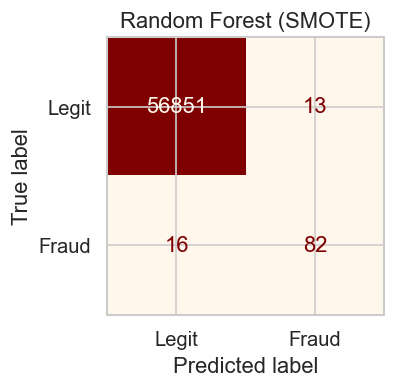

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Random Forest,0.9995,0.8632,0.8367,0.8497,0.9731,0.8696


In [26]:
model_name = 'random_forest'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with SMOTE...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_smote, y_smote)
y_pred = model.predict(X_test)
predictions_smote[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'smote_default')
smote_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (SMOTE)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình Random Forest kết hợp với SMOTE cho thấy hiệu quả cao trong việc xử lý bài toán mất cân bằng dữ liệu. Đặc biệt, recall đối với lớp gian lận (fraud) đạt 83.7%, cho thấy mô hình có khả năng phát hiện phần lớn các giao dịch gian lận.

Đồng thời, precision đạt 86.3%, chứng tỏ mô hình vẫn kiểm soát tốt số lượng dự đoán sai (false positives). Sự cân bằng giữa precision và recall được thể hiện rõ qua F1-score đạt 0.8497, cho thấy mô hình hoạt động ổn định và đáng tin cậy.

Ngoài ra, chỉ số AUC-ROC đạt 0.9731 cho thấy khả năng phân biệt giữa hai lớp (gian lận và hợp lệ) của mô hình là rất tốt.

So với các phương pháp như random under-sampling, SMOTE cho thấy hiệu quả vượt trội hơn khi giúp cải thiện recall mà không làm giảm đáng kể precision. Nhờ đó, mô hình đạt được sự cân bằng tốt hơn giữa việc phát hiện gian lận và hạn chế cảnh báo sai, dẫn đến hiệu suất tổng thể cao hơn.

### 3.2 Logistic Regression


  Training Logistic Regression with SMOTE...

──────────────────────────────────────────────────
  Logistic Regression (smote_default)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



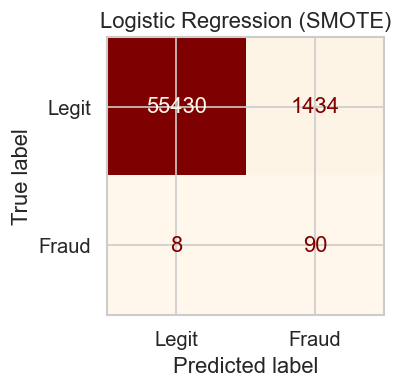

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Logistic Regression,0.9747,0.0591,0.9184,0.111,0.9712,0.7235


In [27]:
model_name = 'logistic_regression'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with SMOTE...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_smote, y_smote)
y_pred = model.predict(X_test)
predictions_smote[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'smote_default')
smote_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (SMOTE)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Mô hình Logistic Regression sau khi áp dụng SMOTE cho thấy khả năng phát hiện các giao dịch gian lận khá tốt, với recall đạt 91.84%. Điều này cho thấy mô hình có thể nhận diện phần lớn các trường hợp fraud.

Tuy nhiên, precision chỉ đạt 5.91%, cho thấy số lượng dự đoán sai (false positives) rất lớn. Nói cách khác, mô hình dự đoán rất nhiều giao dịch là gian lận nhưng phần lớn trong số đó lại không phải, dẫn đến độ chính xác thấp đối với lớp fraud.

Sự mất cân bằng giữa precision và recall khiến F1-score chỉ đạt 0.111, phản ánh hiệu suất tổng thể của mô hình trên lớp gian lận là khá kém. Mặc dù accuracy vẫn cao (~97.47%), nhưng chỉ số này không có nhiều ý nghĩa trong bài toán mất cân bằng dữ liệu.

So với phương pháp random under-sampling, SMOTE vẫn cho kết quả tốt hơn đối với Logistic Regression khi giúp cải thiện đáng kể recall. Tuy nhiên, mô hình vẫn gặp vấn đề lớn về precision, cho thấy Logistic Regression chưa phải là lựa chọn tối ưu cho bài toán này, đặc biệt khi so với các mô hình như Random Forest.

### 3.3 K-Nearest Neighbors


  Training K-Nearest Neighbors with SMOTE...

──────────────────────────────────────────────────
  K-Nearest Neighbors (smote_default)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.43      0.88      0.58        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.79     56962
weighted avg       1.00      1.00      1.00     56962



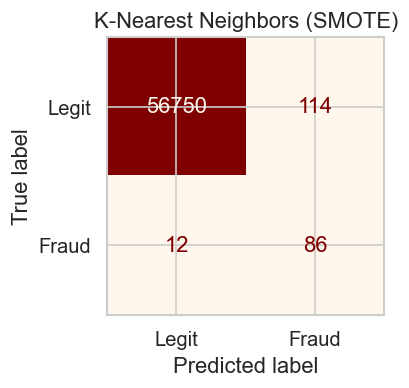

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
K-Nearest Neighbors,0.9978,0.43,0.8776,0.5772,0.9535,0.6102


In [28]:
model_name = 'knn'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with SMOTE...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_smote, y_smote)
y_pred = model.predict(X_test)
predictions_smote[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'smote_default')
smote_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (SMOTE)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Sau khi áp dụng SMOTE, mô hình K-Nearest Neighbors (KNN) cho thấy khả năng phát hiện các giao dịch gian lận khá tốt, với recall đạt 87.76%. Điều này cho thấy mô hình có thể nhận diện phần lớn các trường hợp fraud trong tập dữ liệu.

Đồng thời, precision đạt 43%, cao hơn đáng kể so với Logistic Regression, cho thấy số lượng cảnh báo sai (false positives) đã được giảm bớt. Nhờ đó, mô hình đạt được sự cân bằng tốt hơn giữa precision và recall, thể hiện qua F1-score đạt 0.5772.

Chỉ số AUC-ROC đạt 0.9535 cũng cho thấy khả năng phân biệt giữa hai lớp của mô hình là khá tốt, dù vẫn thấp hơn so với Random Forest.

So với phương pháp random under-sampling, SMOTE tiếp tục cho thấy hiệu quả vượt trội khi giúp cải thiện cả recall và precision, từ đó mang lại sự cân bằng tốt hơn giữa việc phát hiện gian lận và hạn chế dự đoán sai.

### 3.4 Support Vector Machine


  Training Support Vector Machine with SMOTE...

──────────────────────────────────────────────────
  Support Vector Machine (smote_default)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       Legit       1.00      0.99      0.99     56864
       Fraud       0.09      0.88      0.17        98

    accuracy                           0.98     56962
   macro avg       0.55      0.93      0.58     56962
weighted avg       1.00      0.98      0.99     56962



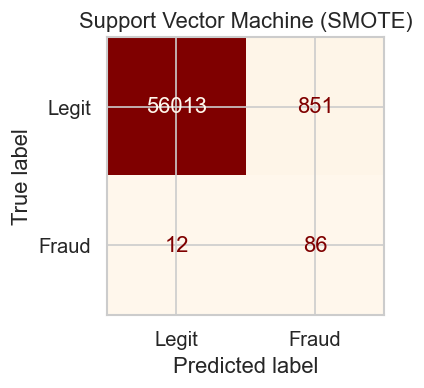

,accuracy,precision,recall,f1_score,auc_roc,auc_pr
Support Vector Machine,0.9848,0.0918,0.8776,0.1662,0.9642,0.608


In [29]:
model_name = 'svm'
print(f'\n{"="*50}')
print(f'  Training {get_model_display_name(model_name)} with SMOTE...')
print(f'{"="*50}')

model = get_model(model_name)
model.fit(X_smote, y_smote)
y_pred = model.predict(X_test)
predictions_smote[model_name] = y_pred

metrics = evaluate_model(model, X_test, y_test, model_name, 'smote_default')
smote_metrics.append({
    'Model': get_model_display_name(model_name),
    **metrics,
})

fig, ax = plt.subplots(1, 1, figsize=(3,3))
display_labels = ['Legit', 'Fraud']
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=display_labels, ax=ax, cmap='OrRd', colorbar=False)
plt.title(f'{get_model_display_name(model_name)} (SMOTE)')
plt.show()

pd.DataFrame(data=[metrics], index=[get_model_display_name(model_name)])

Sau khi áp dụng SMOTE, mô hình Support Vector Machine (SVM) cho thấy sự cải thiện rõ rệt trong khả năng phát hiện các giao dịch gian lận, với recall đạt 87.76%. Điều này cho thấy mô hình có thể nhận diện phần lớn các trường hợp fraud trong tập dữ liệu.

Tuy nhiên, precision chỉ đạt 9.18%, cho thấy số lượng dự đoán sai (false positives) vẫn còn rất cao. Tương tự như Logistic Regression, mô hình SVM có xu hướng ưu tiên bắt được càng nhiều trường hợp gian lận càng tốt, nhưng đánh đổi bằng việc tạo ra nhiều cảnh báo sai.

Sự mất cân bằng giữa precision và recall khiến F1-score chỉ đạt 0.1662, phản ánh hiệu suất tổng thể của mô hình trên lớp gian lận chưa cao. Mặc dù accuracy đạt khoảng 98.48%, nhưng chỉ số này không phản ánh đúng chất lượng mô hình trong bối cảnh dữ liệu mất cân bằng.

So với phương pháp random under-sampling, SMOTE tiếp tục cho thấy hiệu quả tốt hơn khi giúp cải thiện recall mà không làm precision giảm quá mức. Tuy nhiên, mô hình SVM vẫn chưa đạt được sự cân bằng tốt giữa precision và recall, do đó chưa phải là lựa chọn tối ưu so với các mô hình khác như Random Forest hoặc KNN.

### 3.5 Performance comparison

In [30]:
smote_df = pd.DataFrame(smote_metrics)

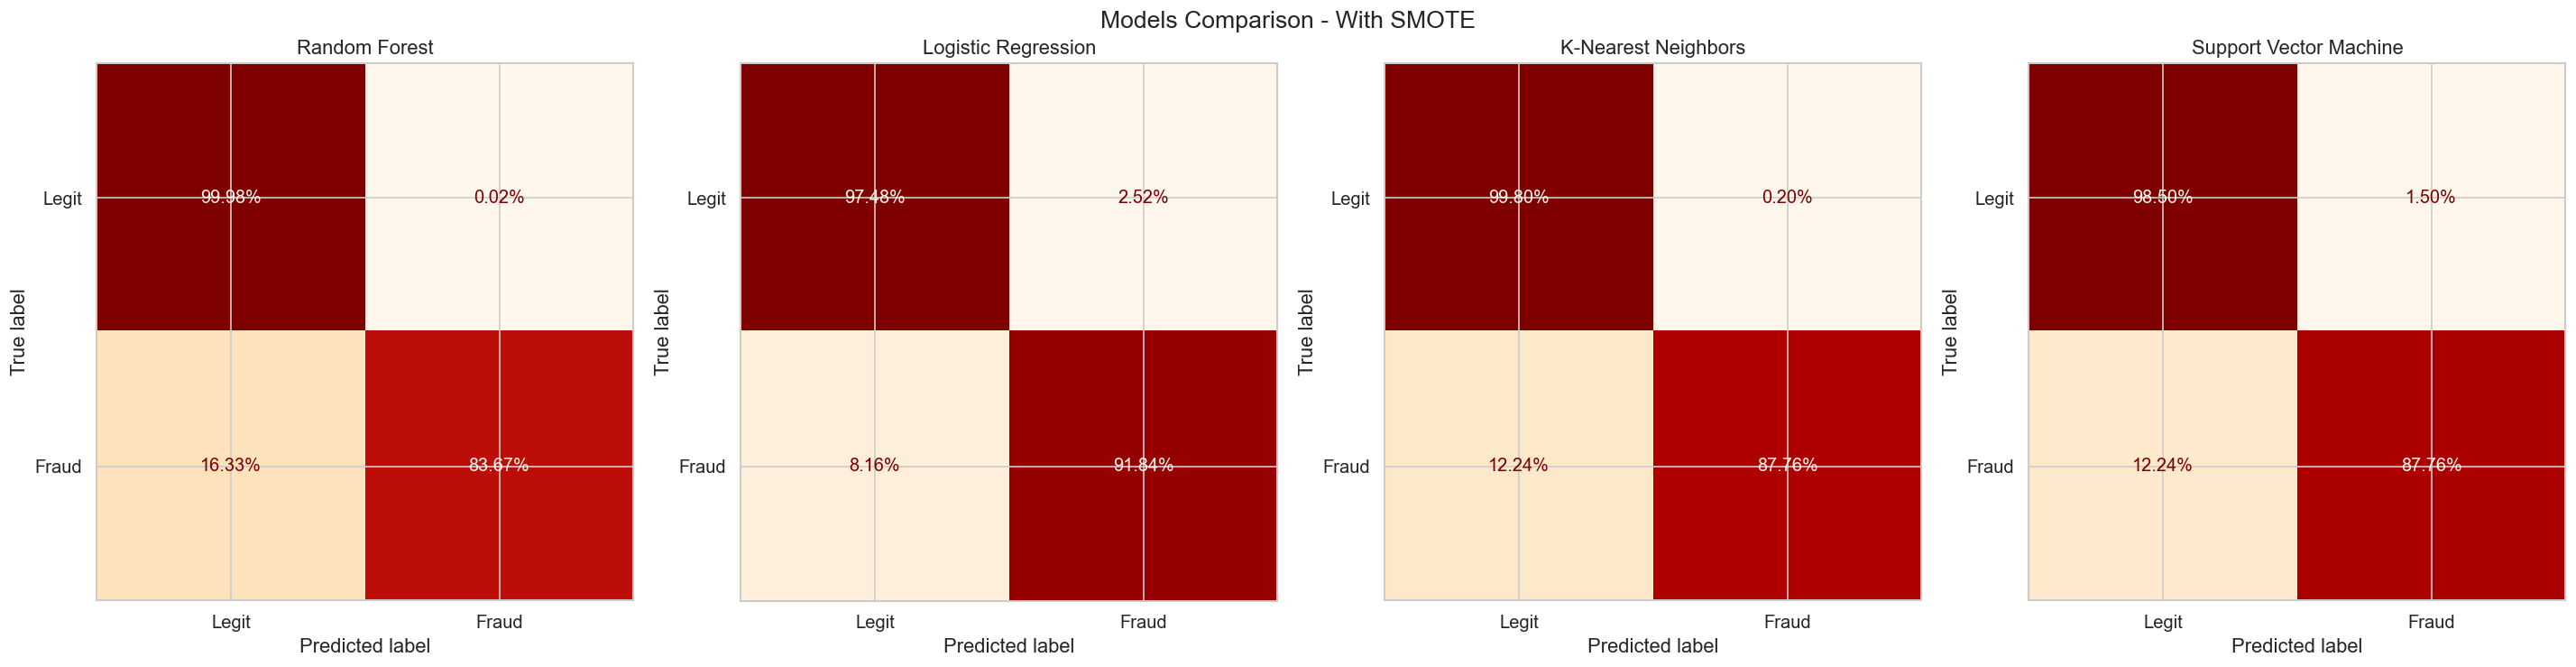

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle('Models Comparison - With SMOTE', fontsize=16)

for j, model_name in enumerate(MODEL_NAMES):
    ax = axes[j]
    ax.set_title(f'{get_model_display_name(model_name)}')
    ConfusionMatrixDisplay.from_predictions(
        y_test, 
        predictions_smote[model_name], 
        display_labels=display_labels, 
        ax=ax, 
        cmap='OrRd', 
        colorbar=False, normalize='true', values_format='.2%', text_kw={'fontsize':12})
    
    
plt.tight_layout()
plt.show()

In [32]:
smote_df = pd.DataFrame(smote_metrics)
print('\n📊 All Models — SMOTE:')
print(smote_df.to_string(index=False))
smote_df.to_csv(REPORTS_DIR / 'all_models_smote.csv', index=False)



📊 All Models — SMOTE:
                 Model  accuracy  precision  recall  f1_score  auc_roc  auc_pr
         Random Forest    0.9995     0.8632  0.8367    0.8497   0.9731  0.8696
   Logistic Regression    0.9747     0.0591  0.9184    0.1110   0.9712  0.7235
   K-Nearest Neighbors    0.9978     0.4300  0.8776    0.5772   0.9535  0.6102
Support Vector Machine    0.9848     0.0918  0.8776    0.1662   0.9642  0.6080


## 4. So Sánh Trực Quan Toàn Bộ 
### 4.1 Confusion Matrix Grid (3x4)


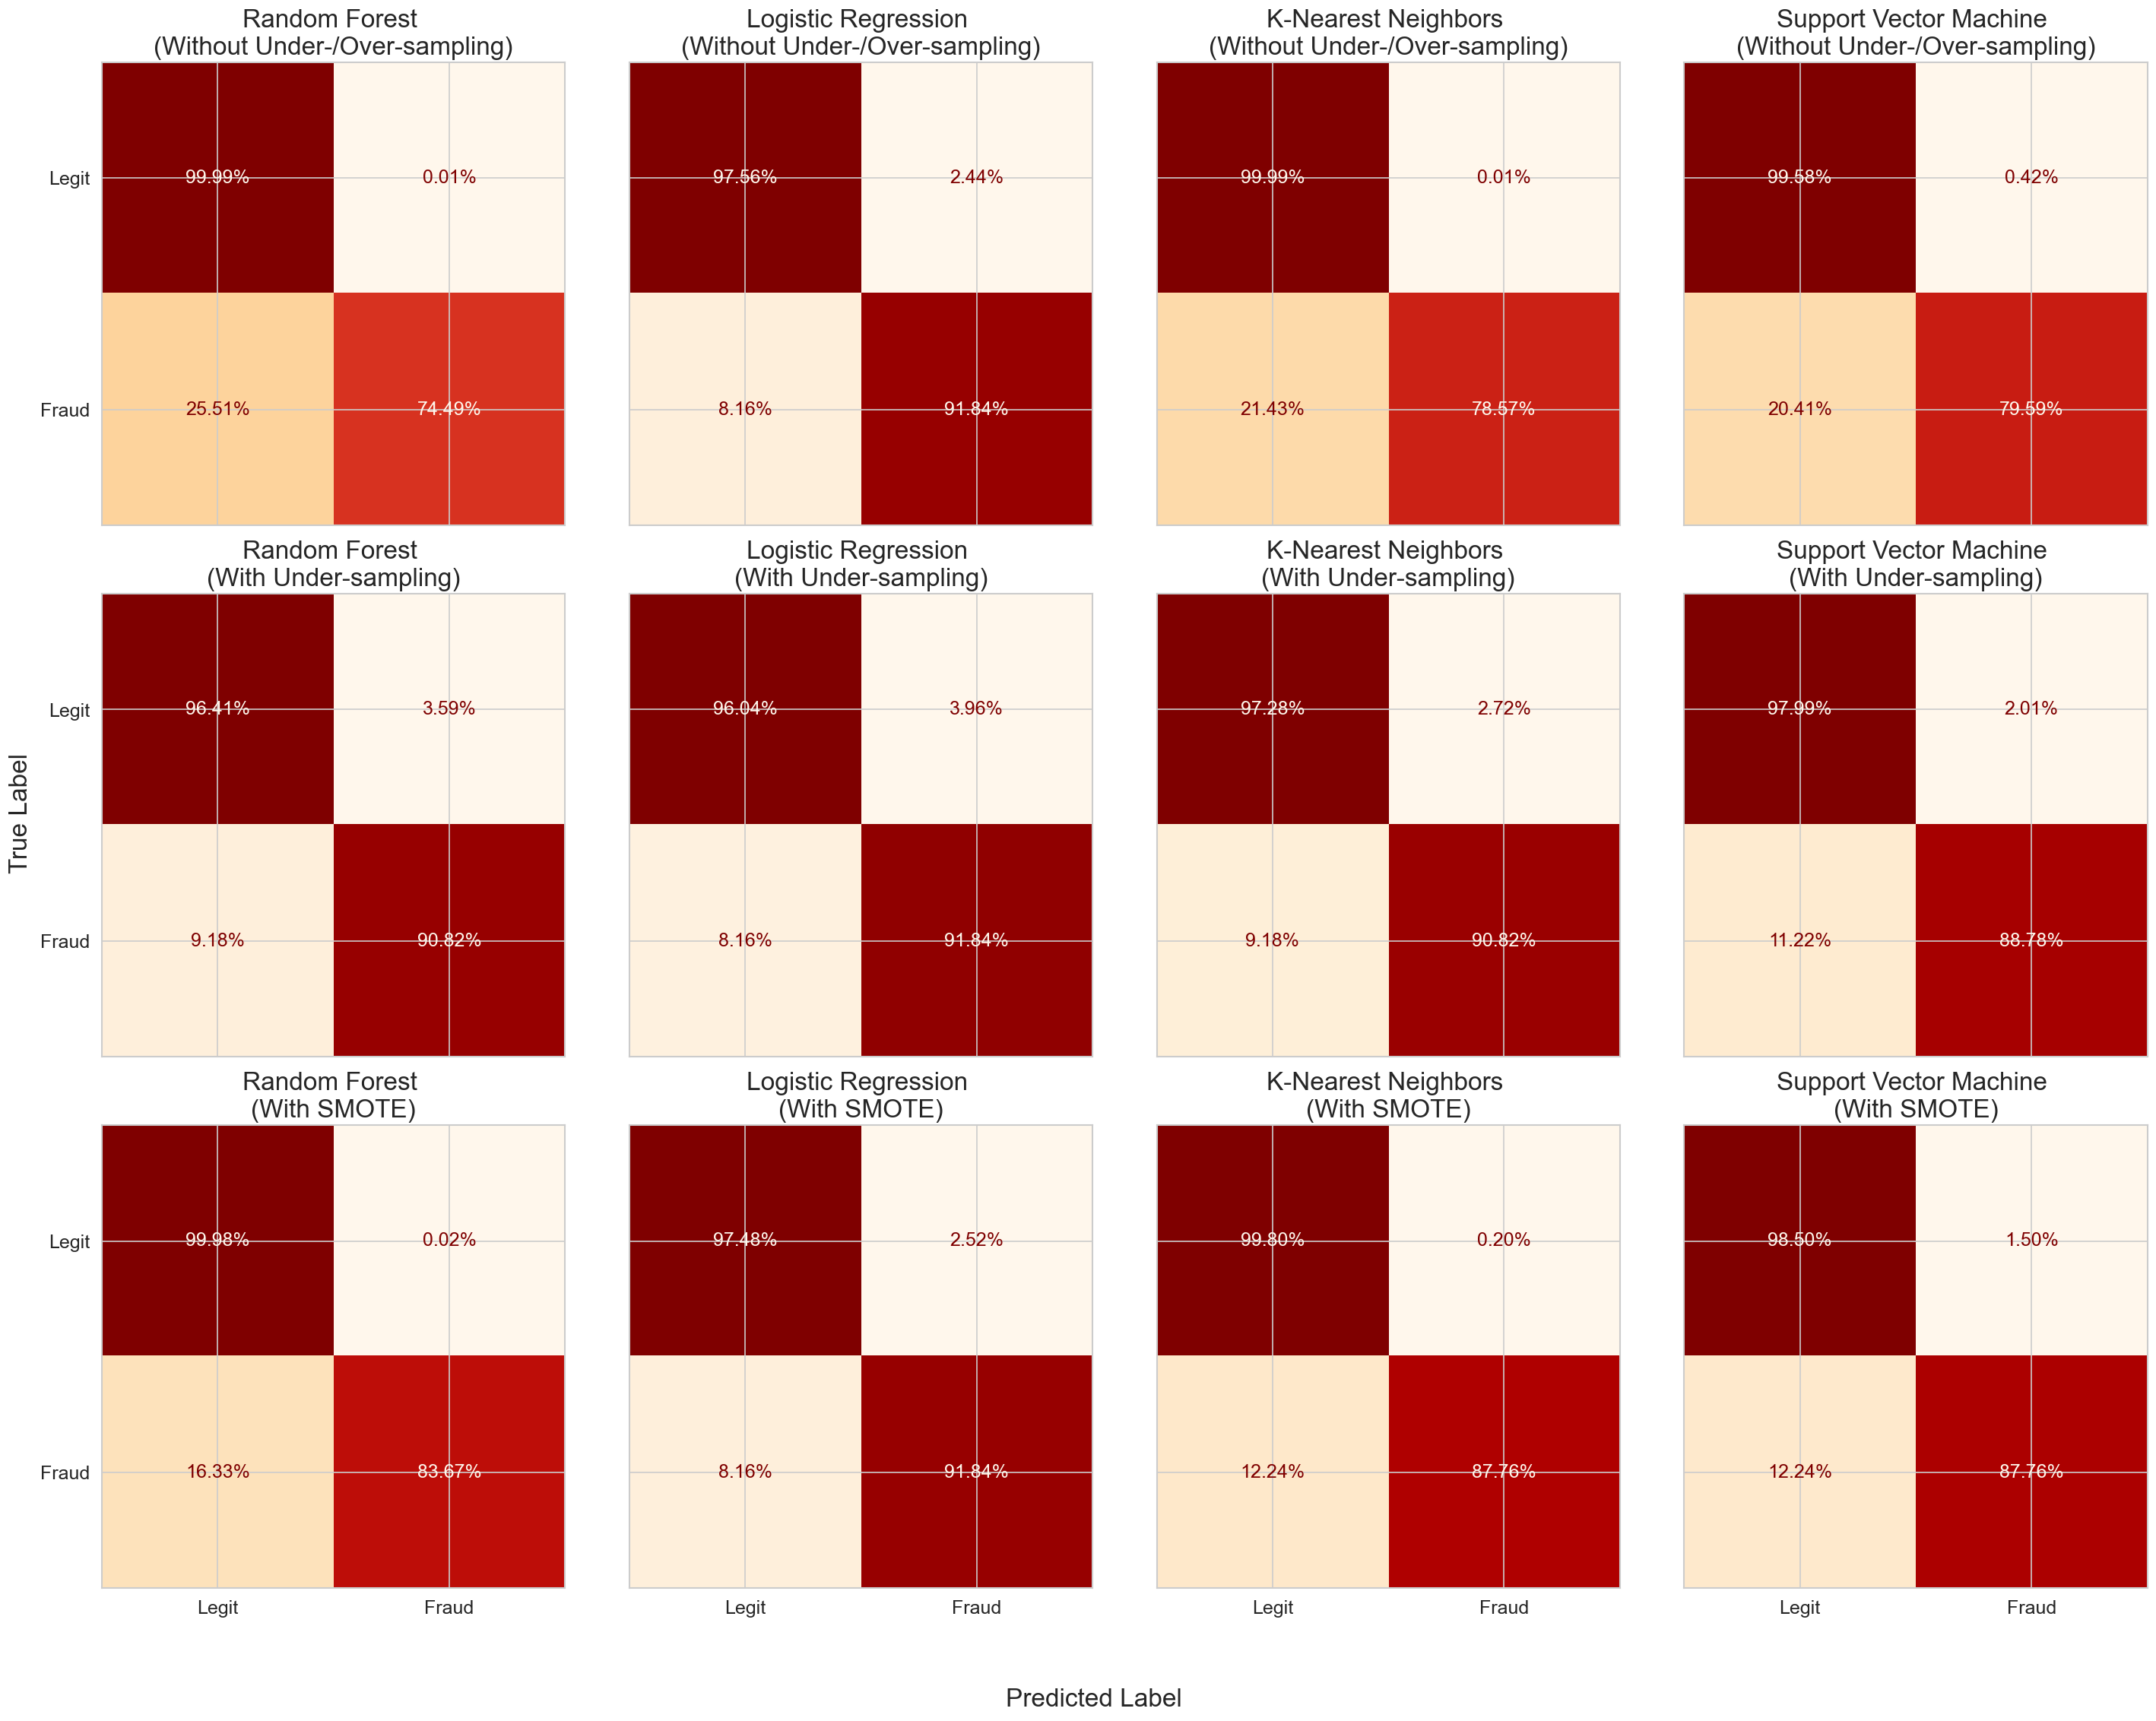

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(3, 4, figsize=(24, 18), sharex=True, sharey=True)

predictions_summary_list = []
for model_name in MODEL_NAMES:
    predictions_summary_list.append(predictions_baseline[model_name])
for model_name in MODEL_NAMES:
    predictions_summary_list.append(predictions_under[model_name])
for model_name in MODEL_NAMES:
    predictions_summary_list.append(predictions_smote[model_name])

models = [get_model_display_name(m) for m in MODEL_NAMES] * 3
techniques = ['Without Under-/Over-sampling'] * 4 + ['With Under-sampling'] * 4 + ['With SMOTE'] * 4

display_labels = ['Legit', 'Fraud']
axes = axes.flatten()

for i, predictions in enumerate(predictions_summary_list):
    ax = axes[i]  
    cm_display = ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=ax, display_labels=display_labels, cmap='OrRd', colorbar=False, normalize='true', values_format='.2%', text_kw={"fontsize":15})
    
    title = f'{models[i]} \n({techniques[i]})'
    cm_display.ax_.set_title(f'{title}', fontsize=20)

    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    axes[i].set_xticklabels(display_labels, fontsize=15)
    axes[i].set_yticklabels(display_labels, fontsize=15)
    
fig.text(0.5, -0.04, 'Predicted Label', ha='center', va='center', fontsize=20)
fig.text(0.01, 0.5, 'True Label', ha='center', va='center', rotation='vertical', fontsize=20)

plt.tight_layout() 
plt.savefig(str(REPORTS_DIR / 'all_models_3x4_confusion_matrices.png'))
plt.show() 


### 4.2 Metrics MultiIndex DataFrame


In [34]:
# Compare the metrics side-by-side in one MultiIndex DataFrame
prediction_summary = pd.concat([baseline_df, under_df, smote_df], ignore_index=True)

iterables = [['Without Under-/Over-sampling', 'With Under-sampling', 'With SMOTE'], list(baseline_df['Model'])]
try:
    index = pd.MultiIndex.from_product(iterables, names=['Technique', 'Model'])
    
    prediction_summary_vals = prediction_summary.drop(columns=['Model']).to_numpy()
    cols = list(prediction_summary.columns)
    cols.remove('Model')
    
    prediction_summary_mi = pd.DataFrame(prediction_summary_vals, index=index, columns=cols)
except Exception as e:
    # Safe fallback if lengths don't match
    prediction_summary_mi = prediction_summary

prediction_summary_mi.head(15)


accuracy  precision  \
Technique                    Model                                         
Without Under-/Over-sampling Random Forest             0.9995     0.9605   
                             Logistic Regression       0.9755     0.0609   
                             K-Nearest Neighbors       0.9995     0.9167   
                             Support Vector Machine    0.9955     0.2468   
With Under-sampling          Random Forest             0.9640     0.0417   
                             Logistic Regression       0.9603     0.0384   
                             K-Nearest Neighbors       0.9726     0.0543   
                             Support Vector Machine    0.9797     0.0707   
With SMOTE                   Random Forest             0.9995     0.8632   
                             Logistic Regression       0.9747     0.0591   
                             K-Nearest Neighbors       0.9978     0.4300   
                             Support Vector Machine    0.9848     0.0918   

                                                     recall  f1_score  \
Technique                    Model                                      
Without Under-/Over-sampling Random Forest           0.7449    0.8391   
                             Logistic Regression     0.9184    0.1141   
                             K-Nearest Neighbors     0.7857    0.8462   
                             Support Vector Machine  0.7959    0.3768   
With Under-sampling          Random Forest           0.9082    0.0798   
                             Logistic Regression     0.9184    0.0738   
                             K-Nearest Neighbors     0.9082    0.1025   
                             Support Vector Machine  0.8878    0.1309   
With SMOTE                   Random Forest           0.8367    0.8497   
                             Logistic Regression     0.9184    0.1110   
                             K-Nearest Neighbors     0.8776    0.5772   
                             Support Vector Machine  0.8776    0.1662   

                                                     auc_roc  auc_pr  
Technique                    Model                                    
Without Under-/Over-sampling Random Forest            0.9529  0.8556  
                             Logistic Regression      0.9720  0.7189  
                             K-Nearest Neighbors      0.9438  0.8449  
                             Support Vector Machine   0.9755  0.4363  
With Under-sampling          Random Forest            0.9778  0.6956  
                             Logistic Regression      0.9761  0.6933  
                             K-Nearest Neighbors      0.9646  0.2139  
                             Support Vector Machine   0.9786  0.6174  
With SMOTE                   Random Forest            0.9731  0.8696  
                             Logistic Regression      0.9712  0.7235  
                             K-Nearest Neighbors      0.9535  0.6102  
                             Support Vector Machine   0.9642  0.6080

## 5.  Kết luận (Conclusion)

Tổng kết đánh giá mô hình:

So sánh kết quả của các mô hình trước khi áp dụng kỹ thuật cân bằng dữ liệu, sau khi áp dụng random under-sampling, và sau khi áp dụng SMOTE cho thấy rằng:

Trước khi resampling, các mô hình có sự chênh lệch rõ rệt về precision và recall. Một số mô hình như Random Forest và KNN đạt precision cao nhưng recall còn hạn chế, trong khi Logistic Regression lại có recall cao nhưng precision rất thấp.
Random under-sampling giúp tăng recall đáng kể cho hầu hết các mô hình (đa số trên 90%), tuy nhiên lại làm giảm mạnh precision, đặc biệt ở các mô hình như Random Forest và Logistic Regression, dẫn đến rất nhiều dự đoán sai (false positives).
SMOTE mang lại sự cải thiện cân bằng hơn giữa precision và recall. Các mô hình sau khi áp dụng SMOTE có xu hướng giữ được recall cao đồng thời cải thiện precision đáng kể so với under-sampling, đặc biệt là với Random Forest và KNN.

Kết quả thực nghiệm cho thấy SMOTE nhìn chung vượt trội hơn so với random under-sampling khi giúp các mô hình đạt được sự cân bằng tốt hơn giữa precision và recall. Trong đó, Random Forest với SMOTE là mô hình nổi bật nhất khi đạt F1-score cao (~0.85), cùng với precision và recall đều ở mức tốt. KNN với SMOTE cũng cho kết quả tương đối ổn định, trong khi Logistic Regression và SVM vẫn gặp vấn đề về precision thấp dù recall cao.

Tuy nhiên, hiệu quả của SMOTE phụ thuộc vào từng mô hình cụ thể. 
Đối với Random Forest và KNN, SMOTE giúp cải thiện rõ rệt sự cân bằng giữa precision và recall. 
Ngược lại, với Logistic Regression và SVM, dù recall vẫn cao, precision vẫn rất thấp, cho thấy các mô hình tuyến tính này chưa phù hợp với bài toán.

Do đó, SMOTE không chỉ cải thiện dữ liệu mà còn giúp làm rõ sự khác biệt về khả năng học của từng mô hình.

Trong bối cảnh bài toán phát hiện gian lận giao dịch thẻ tín dụng, mục tiêu không chỉ là phát hiện càng nhiều giao dịch gian lận càng tốt (recall cao), mà còn phải hạn chế việc gán nhầm các giao dịch hợp lệ thành gian lận (precision cao) để tránh gây phiền hà cho người dùng. Ví dụ, nếu một khách hàng thường xuyên giao dịch hợp lệ nhưng hệ thống liên tục cảnh báo sai, điều này có thể dẫn đến trải nghiệm người dùng kém và giảm độ tin cậy của hệ thống.

Do đó, việc cân bằng giữa precision và recall là rất quan trọng. Chỉ số F1-score, đại diện cho sự hài hòa giữa hai yếu tố này, là một thước đo phù hợp để đánh giá hiệu quả mô hình. Dựa trên kết quả thu được, các mô hình sau khi áp dụng SMOTE, đặc biệt là Random Forest, là lựa chọn phù hợp hơn vì cung cấp sự cân bằng tốt giữa khả năng phát hiện gian lận và hạn chế cảnh báo sai.

Tuy nhiên, việc lựa chọn mô hình cuối cùng vẫn phụ thuộc vào yêu cầu cụ thể của bài toán thực tế, chẳng hạn như mức độ ưu tiên giữa việc giảm thiểu gian lận hay giảm thiểu cảnh báo sai, cũng như các yếu tố về hiệu năng và chi phí tính toán của hệ thống.



